In [2]:
# Instala si no tienes las librerías
# !pip install xgboost imbalanced-learn
!pip install imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

✅ Librerías cargadas correctamente


In [4]:
df = pd.read_csv('../data/raw/dataset_fraude_horarios.csv')

print("Shape:", df.shape)
print("\nDistribución target:")
print(df['es_fraude'].value_counts())
print(f"\n% Fraude: {df['es_fraude'].mean()*100:.2f}%")
df.head()

Shape: (100000, 26)

Distribución target:
es_fraude
0    98000
1     2000
Name: count, dtype: int64

% Fraude: 2.00%


,id_transaccion,id_usuario,fecha,hora,dias_antiguedad_cuenta,email_verificado,gasto_promedio_usuario,hora_habitual_usuario,desviacion_hora,categoria,...,mismo_envio_facturacion,tipo_dispositivo,dispositivo_nuevo,uso_vpn_proxy,tipo_ip,intentos_pago_fallidos,paso_3d_secure,minutos_desde_ultima_tx,tx_ultimas_24h,es_fraude
0,71272,7877,2025-01-01 00:05:00,0,54,1,53.57,12,12,Salud,...,1,Tablet,1,0,Residencial,0,0,999999.0,0.0,0
1,19790,9825,2025-01-01 00:05:00,0,679,1,43.13,10,10,Supermercado,...,1,Físico (TPV),0,0,NaN,0,0,999999.0,0.0,0
2,68204,9542,2025-01-01 00:13:00,0,331,0,40.94,18,6,Supermercado,...,1,Desktop,0,0,Residencial,0,0,999999.0,0.0,0
3,17950,367,2025-01-01 00:15:00,0,572,1,13.64,15,9,Restaurante,...,1,Móvil,1,0,Residencial,0,0,999999.0,0.0,0
4,27640,3962,2025-01-01 00:18:00,0,1449,1,57.75,21,3,Restaurante,...,1,Físico (TPV),0,0,NaN,0,0,999999.0,0.0,0


In [5]:
# tipo_ip es NaN en transacciones físicas (sin IP) → rellenamos
df['tipo_ip'] = df['tipo_ip'].fillna('Sin_IP')

# Eliminamos columnas de identificación que no aportan al modelo
df = df.drop(columns=['id_transaccion', 'id_usuario', 'fecha'])

print("Nulos restantes:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n✅ Dataset limpio")

Nulos restantes:
Series([], dtype: int64)

✅ Dataset limpio


In [6]:
categorical_cols = [
    'categoria', 'tipo_tarjeta', 'pais_emision',
    'pais_pago', 'tipo_dispositivo', 'tipo_ip'
]

numerical_cols = [
    'hora', 'dias_antiguedad_cuenta', 'email_verificado',
    'gasto_promedio_usuario', 'hora_habitual_usuario', 'desviacion_hora',
    'monto', 'ratio_monto_promedio', 'es_online',
    'mismo_envio_facturacion', 'dispositivo_nuevo', 'uso_vpn_proxy',
    'intentos_pago_fallidos', 'paso_3d_secure',
    'minutos_desde_ultima_tx', 'tx_ultimas_24h'
]

X = df.drop(columns=['es_fraude'])
y = df['es_fraude']

print("Features numéricas:", len(numerical_cols))
print("Features categóricas:", len(categorical_cols))
print("Total filas:", len(df))

Features numéricas: 16
Features categóricas: 6
Total filas: 100000


In [7]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Train: {X_train_proc.shape} | Test: {X_test_proc.shape}")
print("✅ Preprocesamiento aplicado")

Train: (80000, 47) | Test: (20000, 47)
✅ Preprocesamiento aplicado


In [8]:
print("Antes de SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print("\nDespués de SMOTE:")
print(pd.Series(y_train_bal).value_counts())
print("✅ Clases balanceadas")

Antes de SMOTE:
es_fraude
0    78400
1     1600
Name: count, dtype: int64

Después de SMOTE:
es_fraude
0    78400
1    78400
Name: count, dtype: int64
✅ Clases balanceadas


In [9]:
scale = y_train.value_counts()[0] / y_train.value_counts()[1]

modelo = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)

modelo.fit(X_train_bal, y_train_bal)
print("✅ Modelo entrenado")

✅ Modelo entrenado


In [10]:
y_pred = modelo.predict(X_test_proc)
y_prob = modelo.predict_proba(X_test_proc)[:, 1]

print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legítimo', 'Fraude']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

📊 Classification Report:
              precision    recall  f1-score   support

    Legítimo       1.00      0.97      0.99     19600
      Fraude       0.40      0.91      0.56       400

    accuracy                           0.97     20000
   macro avg       0.70      0.94      0.77     20000
weighted avg       0.99      0.97      0.98     20000

ROC-AUC Score: 0.9891


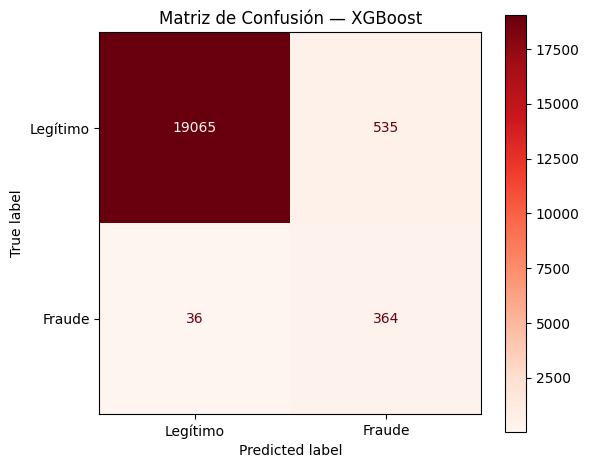

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Legítimo', 'Fraude'],
    cmap='Reds', ax=ax
)
ax.set_title('Matriz de Confusión — XGBoost')
plt.tight_layout()
plt.show()

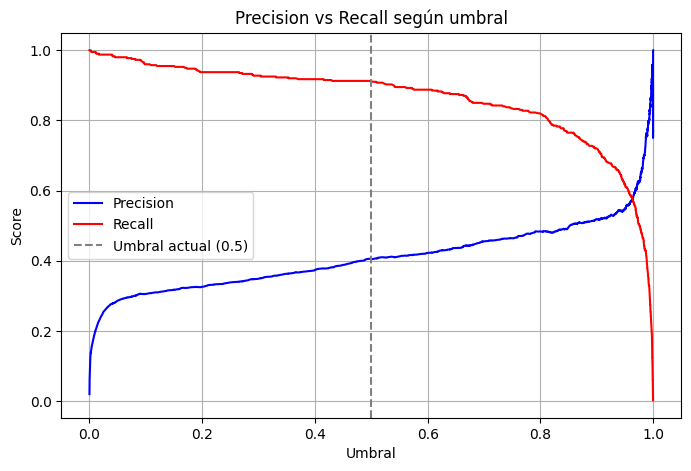


Resultados con umbral 0.7:
              precision    recall  f1-score   support

    Legítimo       1.00      0.98      0.99     19600
      Fraude       0.46      0.85      0.59       400

    accuracy                           0.98     20000
   macro avg       0.73      0.91      0.79     20000
weighted avg       0.99      0.98      0.98     20000



In [12]:
from sklearn.metrics import precision_recall_curve

# Ver cómo cambian precision y recall según el umbral
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Visualizarlo
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
plt.axvline(x=0.5, linestyle='--', color='gray', label='Umbral actual (0.5)')
plt.xlabel('Umbral')
plt.ylabel('Score')
plt.title('Precision vs Recall según umbral')
plt.legend()
plt.grid(True)
plt.show()

# Probar un umbral concreto
umbral = 0.7  # cambia este valor y observa
y_pred_nuevo = (y_prob >= umbral).astype(int)
print(f"\nResultados con umbral {umbral}:")
print(classification_report(y_test, y_pred_nuevo, target_names=['Legítimo', 'Fraude']))

In [13]:
for umbral in [0.6, 0.7, 0.75, 0.8]:
    y_pred_nuevo = (y_prob >= umbral).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_test, y_pred_nuevo)
    r = recall_score(y_test, y_pred_nuevo)
    f1 = f1_score(y_test, y_pred_nuevo)
    print(f"Umbral {umbral} → Precision: {p:.2f} | Recall: {r:.2f} | F1: {f1:.2f}")

Umbral 0.6 → Precision: 0.42 | Recall: 0.89 | F1: 0.57
Umbral 0.7 → Precision: 0.46 | Recall: 0.85 | F1: 0.59
Umbral 0.75 → Precision: 0.46 | Recall: 0.83 | F1: 0.60
Umbral 0.8 → Precision: 0.48 | Recall: 0.82 | F1: 0.61


In [14]:
modelo = XGBClassifier(
    n_estimators=300,       # más árboles
    max_depth=4,            # menos profundidad → menos overfitting
    learning_rate=0.05,     # más fino
    subsample=0.8,          # usa el 80% de filas por árbol
    colsample_bytree=0.8,   # usa el 80% de features por árbol
    random_state=42
)

In [16]:
scale = y_train.value_counts()[0] / y_train.value_counts()[1]

modelo = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [17]:
modelo.fit(X_train_bal, y_train_bal)
print("✅ Modelo entrenado")

✅ Modelo entrenado


In [18]:
y_pred = modelo.predict(X_test_proc)
y_prob = modelo.predict_proba(X_test_proc)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Legítimo', 'Fraude']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

    Legítimo       1.00      0.99      0.99     19600
      Fraude       0.52      0.79      0.62       400

    accuracy                           0.98     20000
   macro avg       0.76      0.89      0.81     20000
weighted avg       0.99      0.98      0.98     20000

ROC-AUC: 0.9900


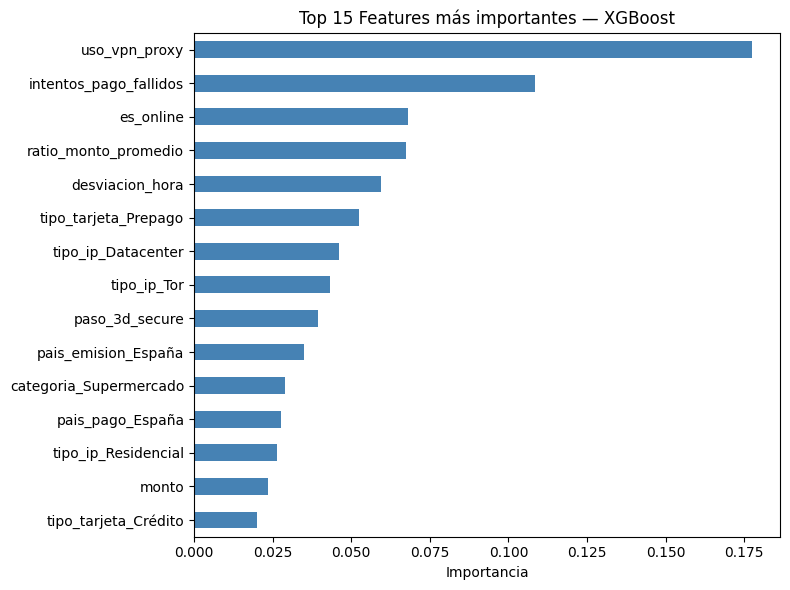

uso_vpn_proxy             0.177530
intentos_pago_fallidos    0.108425
es_online                 0.068072
ratio_monto_promedio      0.067550
desviacion_hora           0.059609
tipo_tarjeta_Prepago      0.052494
tipo_ip_Datacenter        0.046236
tipo_ip_Tor               0.043383
paso_3d_secure            0.039293
pais_emision_España       0.034840
categoria_Supermercado    0.028905
pais_pago_España          0.027744
tipo_ip_Residencial       0.026219
monto                     0.023595
tipo_tarjeta_Crédito      0.020042


In [19]:
feature_names = (
    numerical_cols +
    list(preprocessor.named_transformers_['cat']
         .get_feature_names_out(categorical_cols))
)

importances = pd.Series(modelo.feature_importances_, index=feature_names)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Features más importantes — XGBoost')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

print(top15.to_string())